In [1]:
import numpy as np
import matplotlib.pyplot as plt

tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)

In [2]:
def quantize_at_bitwidth(tensor, bits):

    q_min = -(2**(bits-1)) + 1
    q_max = (2**(bits-1)) - 1

    x_min = np.min(tensor)
    x_max = np.max(tensor)

    scale = max(abs(x_min), abs(x_max)) / q_max

    zero_point = 0

    quantized = np.round(tensor / scale)

    quantized = np.clip(quantized, q_min, q_max)

    quantized = quantized.astype(np.int8)

    dequantized = (quantized - zero_point) * scale

    return quantized, dequantized, scale

In [3]:
def calculate_metrics(original, dequantized):

    error = original - dequantized

    mae = np.mean(np.abs(error))

    mse = np.mean(error**2)

    max_error = np.max(np.abs(error))

    return mae, mse, max_error

In [4]:
bit_widths = [8, 6, 4]

mae_list = []
mse_list = []
max_error_list = []

dequantized_results = []

In [5]:
for bits in bit_widths:

    quantized, dequantized, scale = quantize_at_bitwidth(tensor, bits)

    mae, mse, max_error = calculate_metrics(tensor, dequantized)

    mae_list.append(mae)
    mse_list.append(mse)
    max_error_list.append(max_error)

    dequantized_results.append(dequantized)

    q_min = -(2**(bits-1)) + 1
    q_max = (2**(bits-1)) - 1
    levels = q_max - q_min + 1

    print("\n==============================")
    print(f"{bits}-Bit Quantization")
    print("==============================")

    print("q_min:", q_min)
    print("q_max:", q_max)
    print("Representable Levels:", levels)

    print("Scale:", scale)

    print("Quantized Tensor:")
    print(quantized)

    print("Dequantized Tensor:")
    print(dequantized)

    print("MAE:", mae)
    print("MSE:", mse)
    print("Maximum Error:", max_error)


8-Bit Quantization
q_min: -127
q_max: 127
Representable Levels: 255
Scale: 0.018897638
Quantized Tensor:
[[ -95  -48    0   37   79]
 [-127  -16   11   58  106]]
Dequantized Tensor:
[[-1.7952756  -0.9070866   0.          0.6992126   1.4929134 ]
 [-2.4        -0.3023622   0.20787401  1.096063    2.0031495 ]]
MAE: 0.0037007749
MSE: 2.1638e-05
Maximum Error: 0.007874012

6-Bit Quantization
q_min: -31
q_max: 31
Representable Levels: 63
Scale: 0.077419356
Quantized Tensor:
[[-23 -12   0   9  19]
 [-31  -4   3  14  26]]
Dequantized Tensor:
[[-1.7806451  -0.92903227  0.          0.6967742   1.4709678 ]
 [-2.4        -0.30967742  0.23225807  1.083871    2.0129032 ]]
MAE: 0.015161285
MSE: 0.00036316324
Maximum Error: 0.032258064

4-Bit Quantization
q_min: -7
q_max: 7
Representable Levels: 15
Scale: 0.34285715
Quantized Tensor:
[[-5 -3  0  2  4]
 [-7 -1  1  3  6]]
Dequantized Tensor:
[[-1.7142857  -1.0285715   0.          0.6857143   1.3714286 ]
 [-2.4        -0.34285715  0.34285715  1.0285715 

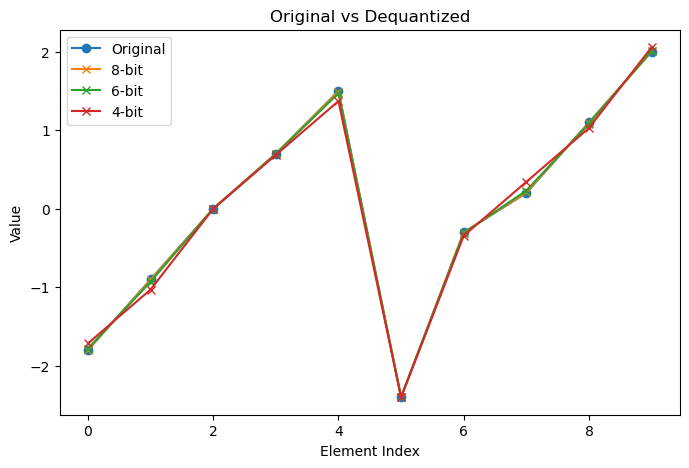

In [6]:
plt.figure(figsize=(8,5))

plt.plot(tensor.flatten(), label="Original", marker="o")

for i, bits in enumerate(bit_widths):
    plt.plot(dequantized_results[i].flatten(),
             marker="x",
             label=f"{bits}-bit")

plt.title("Original vs Dequantized")
plt.xlabel("Element Index")
plt.ylabel("Value")
plt.legend()

plt.show()

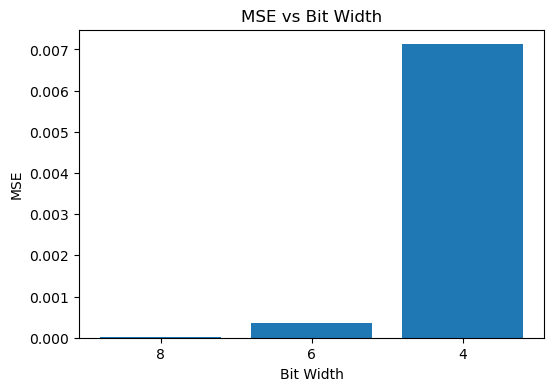

In [7]:
plt.figure(figsize=(6,4))

plt.bar([str(b) for b in bit_widths], mse_list)

plt.title("MSE vs Bit Width")

plt.xlabel("Bit Width")

plt.ylabel("MSE")

plt.show()

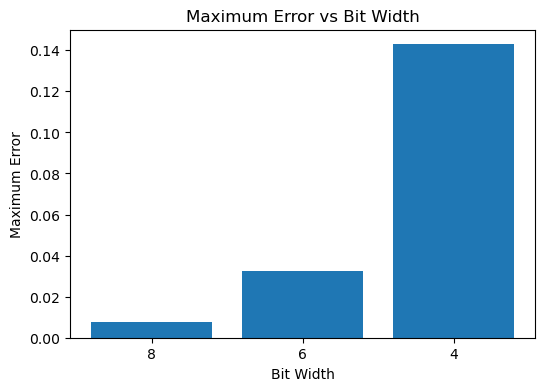

In [8]:
plt.figure(figsize=(6,4))

plt.bar([str(b) for b in bit_widths], max_error_list)

plt.title("Maximum Error vs Bit Width")

plt.xlabel("Bit Width")

plt.ylabel("Maximum Error")

plt.show()